# Final Project: Steam Game Recommender System

### Video Games have become a popular hobby among college students, offering a blend of entertainment, creativity and community. Behind the most famous of video games to the games that are considered hidden and "underrated", data is something that all  games have in common. Our team will use game data to analyze trends, patterns and the performance metrics of various games located on the Steam Platform. Through the analysis of factors such as genre, pricing, user reviews and player engagement, our goal is to provide insights to help the public to better understand what influences game popularity and success. Our project will identify which genre attributes correlate with higher user engagement and overall rating trends.


In [115]:
#Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Data

#### Our Dataset comes from the following github repository: https://github.com/NewbieIndieGameDev/steam-insights This repository contains various fields such as titles, genres, release dates, developer/publisher information, tags, reviews, ratings, and price.


# Importing Dataset

In [116]:
games_df = pd.read_csv('games.csv', engine="python",
    sep=",",
    on_bad_lines="skip",
    encoding="utf-8"
)
categories_df = pd.read_csv('categories.csv')
reviews_df = pd.read_csv('reviews.csv',engine="python",
    sep=",",
    on_bad_lines="skip",
    encoding="utf-8"
)
genres_df = pd.read_csv('genres.csv',engine="python",
    sep=",",
    on_bad_lines="skip",
    encoding="utf-8"
)
steamspy_df = pd.read_csv('steamspy_insights.csv', engine="python",
    sep=",",
    on_bad_lines="skip",
    encoding="utf-8"
)

## Cleaning in Order of Importance

In [117]:
games_df.isna().sum()

app_id             0
name              24
release_date      32
is_free           32
price_overview    32
languages         32
type              32
dtype: int64

In [118]:
categories_df.isna().sum()

app_id      0
category    0
dtype: int64

In [119]:
reviews_df.isna().sum()

app_id                       0
review_score                50
review_score_description    58
positive                    61
negative                    61
total                       61
metacritic_score            66
reviews                     68
recommendations             68
steamspy_user_score         68
steamspy_score_rank         68
steamspy_positive           68
steamspy_negative           68
dtype: int64

In [120]:
genres_df.isna().sum()

app_id    0
genre     0
dtype: int64

In [121]:
steamspy_df.isna().sum()

app_id                         0
developer                      3
publisher                     35
owners_range                   0
concurrent_users_yesterday     0
playtime_average_forever       0
playtime_average_2weeks        0
playtime_median_forever        0
playtime_median_2weeks         0
price                          0
initial_price                  0
discount                       0
languages                      0
genres                         0
dtype: int64

Since the number of na is so small when considering our dataset we can comfortably remove rows with missing instead of using a form of imputatio

In [122]:
reviews_df = reviews_df.dropna()
categories_df = categories_df.dropna()
genres_df = genres_df.dropna()
steamspy_df = steamspy_df.dropna()
games_df = games_df.dropna()

## Checking Duplicates

In [123]:
reviews_df.duplicated().sum()

np.int64(0)

In [124]:
categories_df.duplicated().sum()

np.int64(0)

In [125]:
genres_df.duplicated().sum()

np.int64(0)

In [126]:
steamspy_df.duplicated().sum()


np.int64(0)

In [127]:
games_df.duplicated().sum()

np.int64(0)

## Standardizing Data

Making sure release date is in datetime format, and year is in year format

In [128]:
games_df["release_date"] = pd.to_datetime(games_df["release_date"], errors='coerce')
games_df['release_year'] = games_df['release_date'].dt.year

Making languages numerical

In [129]:
steamspy_df["languages"] = steamspy_df["languages"].apply(lambda x: len(x.split(',')) if isinstance(x, str) else 0)

Ensuring Values of review are numerical

In [130]:
#### Ensuring review numbers are int and not str
reviews_df['positive'] = pd.to_numeric(reviews_df['positive'], errors='coerce')
reviews_df['negative'] = pd.to_numeric(reviews_df['negative'], errors='coerce')
reviews_df['total'] = pd.to_numeric(reviews_df['total'], errors='coerce')
reviews_df['review_score'] = pd.to_numeric(reviews_df['review_score'], errors='coerce')
reviews_df['metacritic_score'] = pd.to_numeric(reviews_df['metacritic_score'], errors='coerce')

Ensuring price data is numerical

In [131]:
steamspy_df['price'] = pd.to_numeric(steamspy_df['price'], errors='coerce')
steamspy_df['initial_price'] = pd.to_numeric(steamspy_df['initial_price'], errors='coerce')


Checking for similarities in app_id column

In [132]:
games_df.head()
reviews_df.head()
steamspy_df.head()
genres_df.head()
categories_df.head()

,app_id,category
0,10,Family Sharing
1,10,Multi-player
2,10,Online PvP
3,10,PvP
4,10,Shared/Split Screen PvP


## Feature Engineering

### Creating a new feature called likability that combines positive review ratio, review score, metacritic score
### Also combining the different dataframes using app_id

In [133]:
#### Creating a new feature called postive_review_ratio that divides positive reviews by total reviews
reviews_df['positive_review_ratio'] = reviews_df['positive'] / reviews_df['total']

#### Creating a new feature called likability that combines postive review ratio, review score, metacritic score
reviews_df['likability'] = (reviews_df['positive_review_ratio'] + reviews_df['review_score'] / 100 + reviews_df['metacritic_score'] / 100) / 3

#making all app_id's the same datatype
for df in [games_df, categories_df, reviews_df, genres_df, steamspy_df]:
    df['app_id'] = df['app_id'].astype(str)

#merge the dataframes using app_id
merged_df = games_df.merge(steamspy_df, on="app_id", how="inner") \
.merge(reviews_df, on="app_id", how="inner") \
.merge(categories_df, on="app_id", how="left") \
.merge(genres_df, on="app_id", how="left")

#determining release year intervals
merged_df['release_bin'] = pd.cut(
    merged_df['release_year'],
    bins=[1980, 2005, 2015, 2020, 2025],
    labels=['Old', 'Mid', 'Modern', 'Recent']
)



### Encoding Genres and Release Bins

In [134]:
#Applying genre numerical values
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
merged_df['genre_encoded'] = le.fit_transform(merged_df['genre'])

#Encoding release year interval values
le_year = LabelEncoder()
merged_df['release_bin_encoded'] = le_year.fit_transform(
    merged_df['release_bin'].astype(str)
)

In [135]:
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(mapping)


{'Abenteuer': np.int64(0), 'Acceso anticipado': np.int64(1), 'Acción': np.int64(2), 'Accounting': np.int64(3), 'Action': np.int64(4), 'Adventure': np.int64(5), 'Akcja': np.int64(6), 'Akční': np.int64(7), 'Animation & Modeling': np.int64(8), 'Audio Production': np.int64(9), 'Aventura': np.int64(10), 'Aventure': np.int64(11), 'Ação': np.int64(12), 'Carreras': np.int64(13), 'Casual': np.int64(14), 'Course automobile': np.int64(15), 'Deportes': np.int64(16), 'Design & Illustration': np.int64(17), 'Dobrodružné': np.int64(18), 'Early Access': np.int64(19), 'Education': np.int64(20), 'Estratégia': np.int64(21), 'Free To Play': np.int64(22), 'Free to Play': np.int64(23), 'Free-to-play': np.int64(24), 'Game Development': np.int64(25), 'Gelegenheitsspiele': np.int64(26), 'Gore': np.int64(27), 'Grátis para Jogar': np.int64(28), 'Indie': np.int64(29), 'Indépendant': np.int64(30), 'Kostenlos spielbar': np.int64(31), 'MMO': np.int64(32), 'Massively Multiplayer': np.int64(33), 'Massivement multijoueu

In [ ]:
## Merging DataFrames on App ID
#kyle: i had to change up the way merged_df was created earlier since i was getting errors
#i changed the way we merged the dataframe as well, i hope that's alright.
#merged_df = pd.concat([games_df, steamspy_df], axis=1, join='inner', ignore_index=False)
#merged_df = pd.concat([merged_df, categories_df], axis=1, join='inner', ignore_index=False)
#merged_df = pd.concat([merged_df, reviews_df], axis=1, join='inner', ignore_index=False)
#merged_df = pd.concat([merged_df, genres_df], axis=1, join='inner', ignore_index=False)

## Saving Dataframe as CSV

In [137]:
merged_df.to_csv('merged_steam_data.csv', index=False)

## Experimenting

#### We will attempt to do clustering through K-Means for numerical Pattern clusters and possible Hierarchical Clustering for visualizing game similarities


#### K means Clustering by likability looking into genre

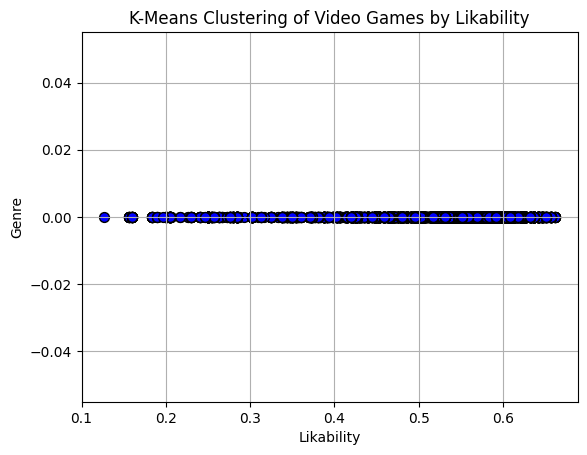

In [138]:
X = merged_df[['likability']]
y = merged_df['genre']

fig = plt.figure(0)
plt.grid(True)
plt.scatter(X, np.zeros_like(X), c='blue', marker='o', edgecolor='k', s=50)
plt.title('K-Means Clustering of Video Games by Likability')
plt.xlabel('Likability')
plt.ylabel('Genre')
plt.show()


In [139]:
#Creating features and its matrix
features = [
    'review_score',
    'metacritic_score',
    'price',
    'positive_review_ratio',
    'genre_encoded',
    'release_bin_encoded'
]
X = merged_df[features].dropna()

# Scaling the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Using the elbow method to find the best K clusters

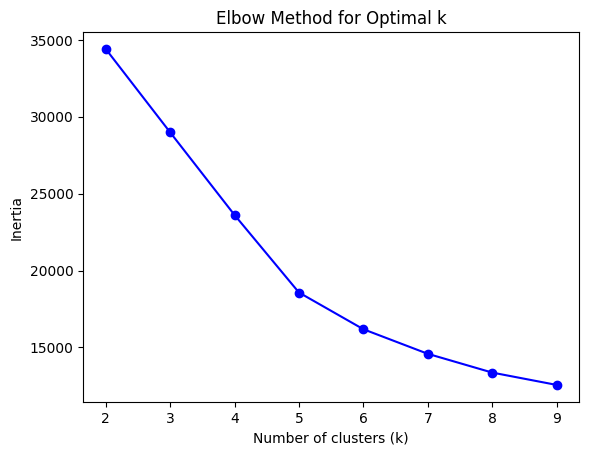

In [140]:
# Elbow method to find best K clusters
inertia = []
K = range(2, 10)

for k in K:
    model = KMeans(n_clusters=k, n_init=10, random_state=42)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

Evaluating using silhouette

In [141]:
from sklearn.metrics import silhouette_score

for k in range(2, 10):
    model = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f'k={k}, silhouette={score:.3f}')


k=2, silhouette=0.202
k=3, silhouette=0.226
k=4, silhouette=0.288
k=5, silhouette=0.334
k=6, silhouette=0.285
k=7, silhouette=0.290
k=8, silhouette=0.291
k=9, silhouette=0.280


Because k = 5 had the most ideal silhouette score, and the curve flattened a lot using the elbow method at k = 5, we will use that for the model

In [142]:
best_k = 5

final_kmeans = KMeans(n_clusters=best_k, n_init=10, random_state=42)
cluster_labels = final_kmeans.fit_predict(X_scaled)

# attach the cluster labels back to the same rows for X
merged_df = merged_df.loc[X.index].copy()
merged_df['cluster'] = cluster_labels

Interpreting the popular clusters

In [143]:
cluster_summary = merged_df.groupby('cluster')[[
    'review_score',
    'metacritic_score',
    'price',
    'positive_review_ratio'
]].mean().round(2)

print(cluster_summary)

         review_score  metacritic_score    price  positive_review_ratio
cluster                                                                
0                0.00             73.23     0.00                   0.93
1                6.81             75.77    13.70                   0.81
2                2.24             60.29    14.43                   0.39
3                6.74             79.48    31.57                   0.80
4                7.75             80.94  3594.46                   0.87
